<a href="https://colab.research.google.com/github/MInesGomes/AI-Project2026/blob/main/InesGomes_AI_BusinessProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Goal: Predict whether a ticket will be solved quickly or not.

We'll use this data set for training
https://www.kaggle.com/datasets/akashbommidi/customer-support-data

In [ ]:
# TODO pip install

## **1. Load the Dataset**

In [4]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("akashbommidi/customer-support-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-support-data' dataset.
Path to dataset files: /kaggle/input/customer-support-data


In [7]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path, 'Customer_support_data.csv'))
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

## **2. Explore the Data**


In [ ]:
print(df.columns)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')



*   **Unique id**: A unique identifier for each customer support ticket. Used for tracking, not used in modeling.
*   **channel_name**: The communication channel used by the customer (e.g., Email, Chat, Phone), which influences response quality and time.
*   **category**: Broad classification of the support issue (e.g., Technical, Billing, Account), useful in understanding issue trends.
*   **Sub-category**: More specific issue label under each category (e.g., "Login Failure" under Technical) to capture granular insights.
*   **Customer Remarks**: Free-text input from customers about their issue; useful for sentiment analysis or NLP-based features.
*   **Order_id**: The ID of the order associated with the issue; may not be directly useful unless joined with order metadata.
*   **order_date_time**: Timestamp of the order; can be used to derive delays or time gaps relative to issue date.
*   **Issue_reported at**: Time when the customer reported the issue; helps calculate response and resolution delays.
*   **issue_responded**: Time when the support agent responded; combined with report time to calculate response duration.
*   **Survey_response_Date**: Date when customer gave the CSAT feedback; useful to understand follow-up timing, but not always predictive.
*   **Customer_City**: The city where the customer resides; can identify location-based trends or systemic issues.
*   **Product_category**: The type of product involved in the support ticket; some product types may result in higher or lower CSAT.
*   **Item_price**: Price of the item involved; higher prices might lead to higher customer expectations and affect satisfaction.
*   **connected_handling_time**: Total time spent by the agent resolving the issue; excessive durations may signal complexity or inefficiency.
*   **Agent_name**: Name of the support agent handling the ticket; can be encoded to understand individual performance impact.
*   **Supervisor**: The agent’s supervisor; useful to analyze team-level trends in CSAT.
*   **Manager**: The manager overseeing the support process; can help identify management-level influence on support quality.
*   **Tenure Bucket**: Agent experience group (e.g., 0–6 months, 6–12 months); more experienced agents might resolve issues better.
*   **Agent Shift**: Time shift during which the case was handled (e.g., Day, Night); night shifts might see different trends in CSAT.
*   **CSAT Score (Target Variable)**: Customer satisfaction score (1 to 5); the main variable we aim to classify using other features.

In [ ]:
print("Descriptive statistics for df_local_csv:")
display(df.describe(include='all'))

Descriptive statistics for df_local_csv:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09-08-2023 11:55,13-08-2023 10:40,28-08-2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


**Key Observations from customer support data:**

*   **Unique id, Order_id:** These columns have a count equal to their unique values, indicating each entry is distinct, as expected for identifiers.
*   **channel_name:** There are 3 unique channels, with 'Inbound' being the most frequent (68142 occurrences).
*   **category:** 12 unique categories exist, with 'Returns' being the most common (44097 occurrences).
*   **Sub-category:** There are 57 unique sub-categories, and 'Reverse Pickup Enquiry' is the most frequent.
*   **Customer Remarks:** This column has a significant number of missing values (only 28742 out of 85907 are non-null), suggesting it might require imputation or careful handling if used for analysis. 'Good' is the most frequent remark.
*   **order_date_time, Customer_City, Product_category, Item_price, connected_handling_time:** These columns also have many missing values, indicating that not all customer interactions are associated with order details, specific products, or cities. `Item_price` and `connected_handling_time` are numerical and show their mean, std, min, max, and quartiles.

Maybe we can drop everything except Item_price, as it could help us predict whether a ticket will be solved quickly or not.
*   **Issue_reported at, issue_responded, Survey_response_Date:** These appear to be date-time strings, with `issue_responded` having a top value of '28-08-2023 00:00' and `Survey_response_Date` '28-Aug-23', suggesting a concentration of responses on certain dates or a default value.
*   **Agent_name, Supervisor, Manager, Tenure Bucket, Agent Shift, CSAT Score:** These columns provide details about the support agents and their performance/attributes. There are many unique agent names (1371), and 'Wendy Taylor' is the most frequent. `CSAT Score` is an integer column, likely indicating satisfaction ratings.


## **3. Data Vizualization**

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the color palette for visualizations
palette = 'hls'
'Set2'

#### CSAT Distribution

/tmp/ipykernel_4770/2940171365.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="CSAT Score", palette = 'hls', legend=False)


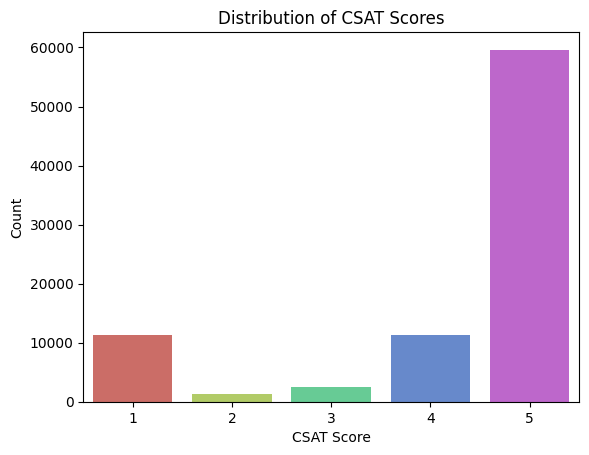

In [18]:
# Visualize the distribution of CSAT Scores using a count plot
sns.countplot(data=df, x="CSAT Score", palette = palette, legend=False)

# Add title and labels to the plot
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

# Display the plot
plt.show()

The chart reveals a strong positive skew, with the majority of responses being a score of 5, indicating high customer satisfaction. Lower scores, like 2 and 3, are much less frequent.



Understanding that most customers are very satisfied can guide the business to maintain existing practices while focusing on areas of improvement for lower scores. This insight can enhance customer satisfaction strategies.



#### CSAT Score vs Avg Response Time

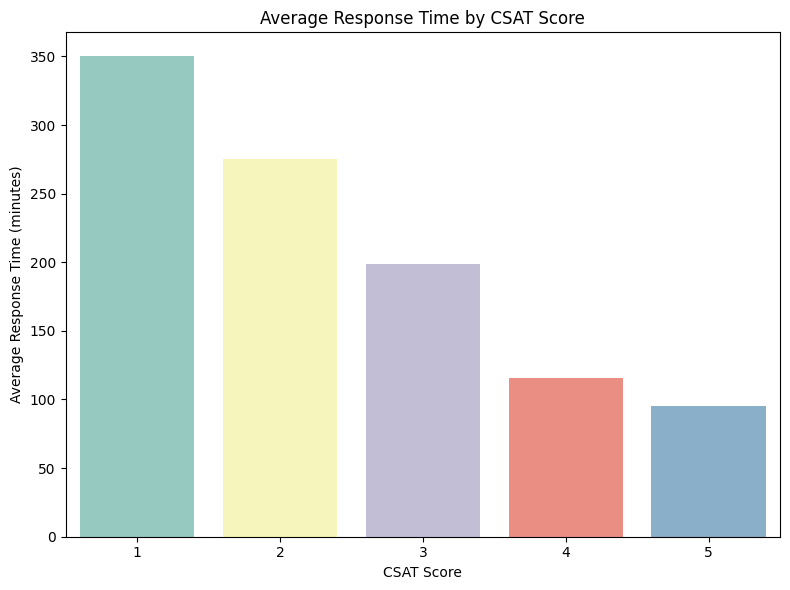

In [ ]:
# Calculate average response time for each CSAT Score
average_response_time = df.groupby('CSAT Score')['response_time_minutes'].mean().reset_index()

# Plot the average response time by CSAT Score
plt.figure(figsize=(8, 6))
sns.barplot(data=average_response_time, x='CSAT Score', y='response_time_minutes', palette='Set3')

# Add title and labels to the plot
plt.title('Average Response Time by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Average Response Time (minutes)')

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

There is a clear inverse relationship between response time and satisfaction. Faster response times correlate with higher CSAT scores.

By focusing on reducing response times, the business can potentially increase customer satisfaction, improving overall service quality and perception.



#### Tickets by Category (Volume)

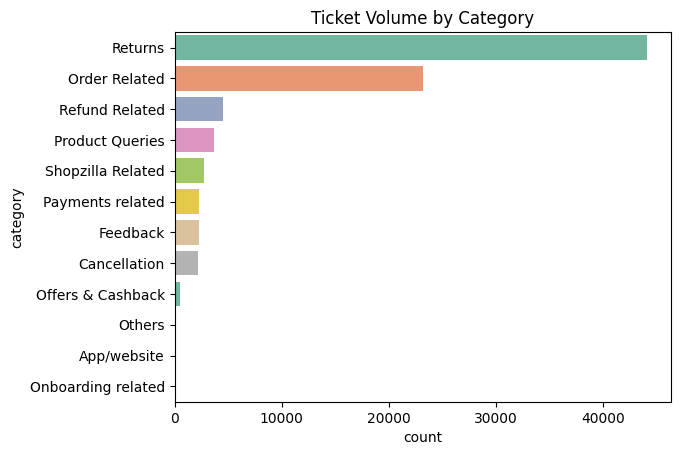

In [ ]:
# Visualize ticket volume by category using a count plot
sns.countplot(data=df, y="category", order=df['category'].value_counts().index, palette=palette)

# Add title to the plot
plt.title("Ticket Volume by Category")

# Display the plot
plt.show()

"Returns" and "Order Related" categories have the highest ticket volumes, indicating pain points. "Onboarding related" and "App/website" have the lowest volumes.



By focusing on reducing ticket volumes in high-traffic areas, the business can enhance efficiency and customer satisfaction, leading to better resource allocation.



#### CSAT by Category (Avg Score )

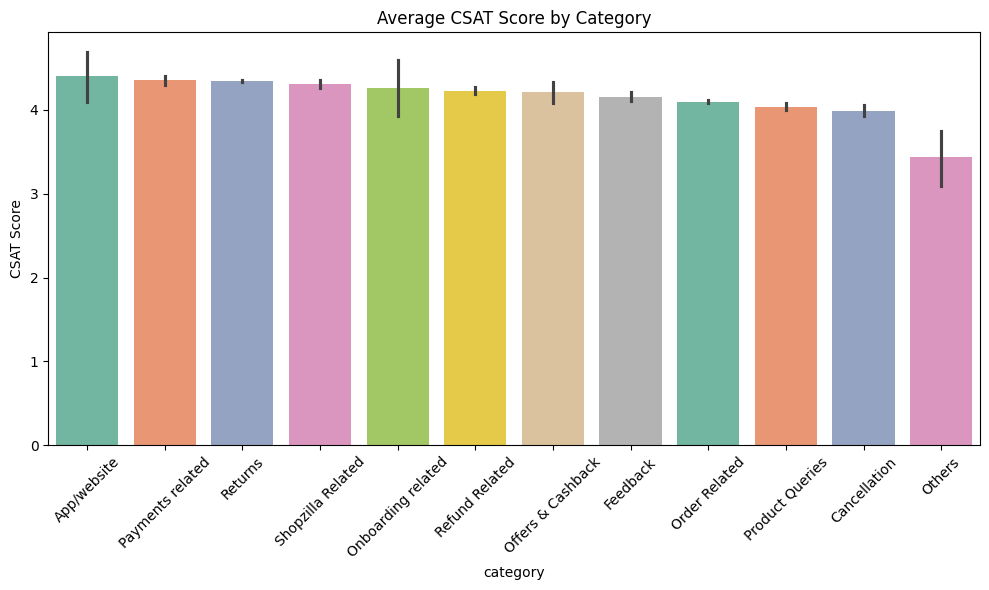

In [ ]:
# Calculate the mean CSAT Score for each category and sort in descending order
mean_scores = df.groupby('category')['CSAT Score'].mean().sort_values(ascending=False)

# Plot the bar chart of mean CSAT Scores by category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='CSAT Score', order=mean_scores.index, palette='Set2')

# Add title, rotate x-axis labels, and ylabel
plt.title("Average CSAT Score by Category")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

Scores are generally high across categories, but "Others" has noticeably lower satisfaction. Categories like "App/Website" and "Onboarding" perform well.



By identifying lower satisfaction in the "Others" category, targeted efforts can be made to address specific issues, improving overall customer satisfaction and experience.



#### CSAT by Sub-category (Avg Score )

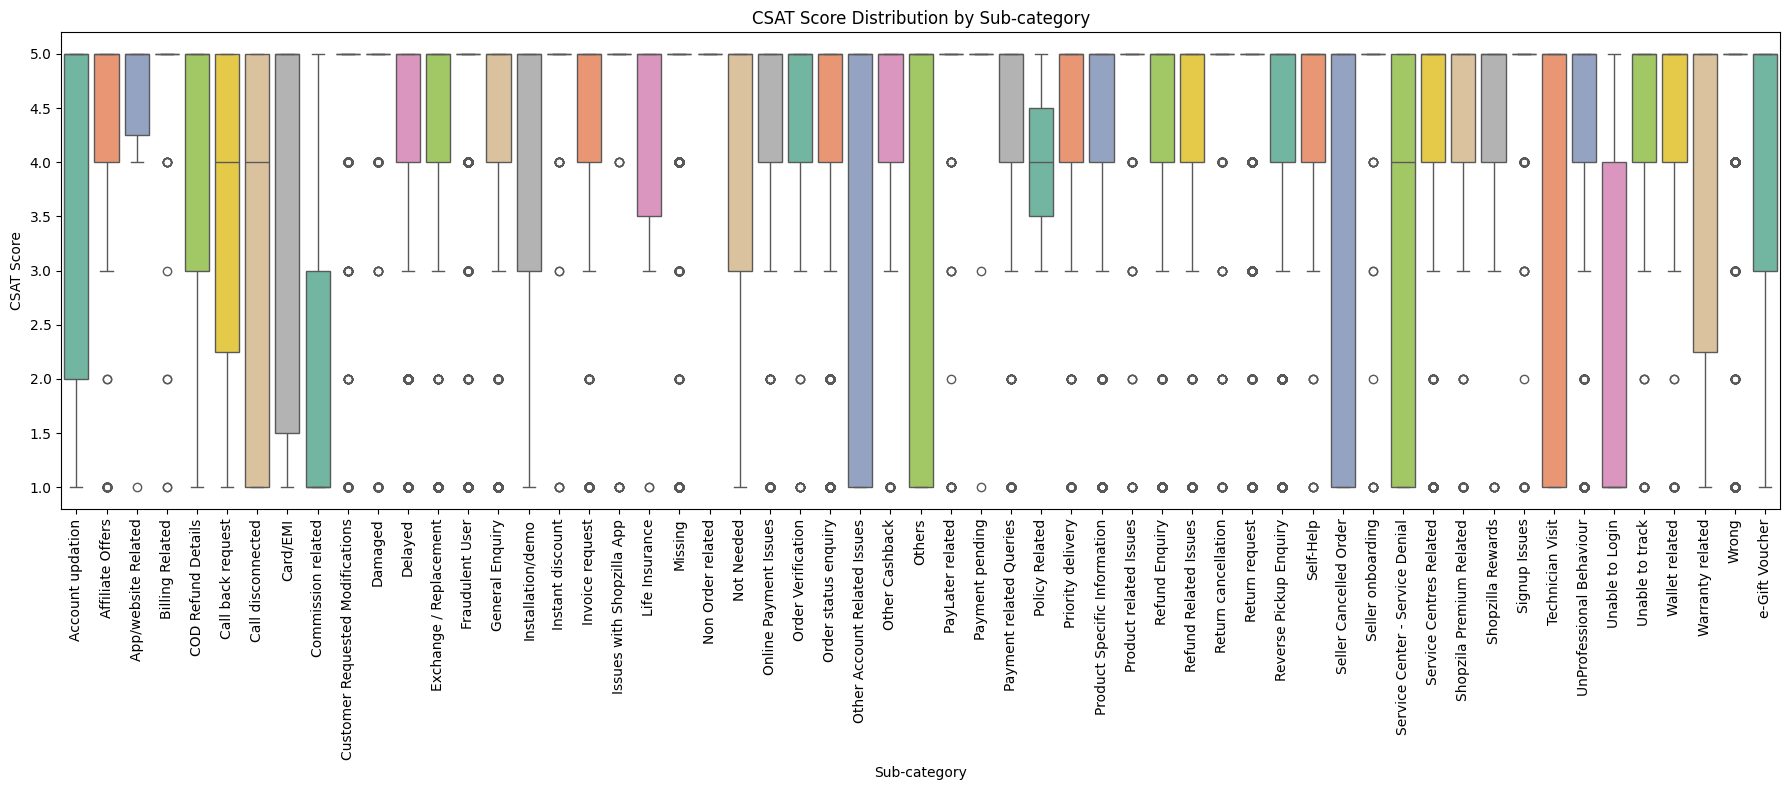

In [ ]:
# Set the figure size to be wider to accommodate all sub-categories
plt.figure(figsize=(18, 8))

# Create a box plot for CSAT Score distribution by Sub-category
sns.boxplot(data=df, x='Sub-category', y='CSAT Score', palette=palette)

# Add title and labels to the plot
plt.title("CSAT Score Distribution by Sub-category")
plt.xticks(rotation=90)  # Rotate x-axis labels for clarity
plt.xlabel("Sub-category")
plt.ylabel("CSAT Score")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

There is significant variability in CSAT scores across sub-categories. Some have high median scores while others show a wider spread and lower scores, indicating areas needing improvement.



Identifying sub-categories with lower scores and higher variability can direct targeted improvements, enhancing overall customer satisfaction and service quality.



#### Agents by Number of Calls Handled (Top 15 )

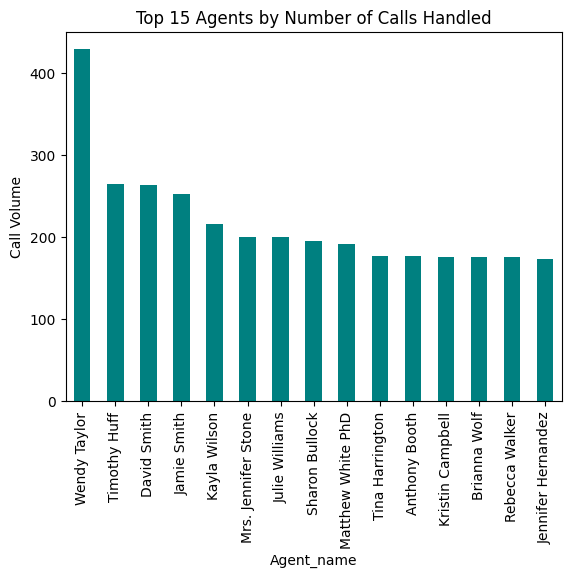

In [ ]:
# Identify the top 15 agents by call volume
top_agents = df['Agent_name'].value_counts().head(15)

# Plot a bar chart of call volume for the top 15 agents
top_agents.plot(kind='bar', title='Top 15 Agents by Number of Calls Handled', color='Teal')

# Add a label for the y-axis
plt.ylabel("Call Volume")

# Display the plot
plt.show()

Wendy Taylor leads with the highest call volume, indicating her significant contribution or high workload among agents.





Redistributing calls can balance workloads, reduce burnout, and potentially improve service efficiency and employee satisfaction.





#### Visualization - 16 : Correlation Heatmap

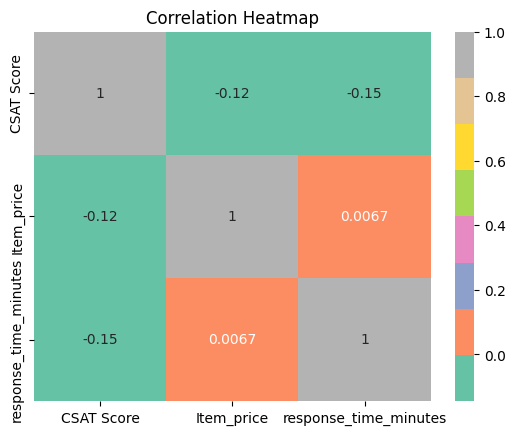

In [ ]:
# Calculate correlation matrix for specified columns
corr = df[["CSAT Score", "Item_price", "response_time_minutes"]].corr()

# Visualize the correlations with a heatmap
sns.heatmap(corr, annot=True, cmap='Set2')

# Add title to the heatmap
plt.title("Correlation Heatmap")

# Show the plot
plt.show()

The heatmap clearly visualizes correlations between variables, highlighting relationships through color intensity.




The correlation heatmap shows:

**Price Sensitivity:** Higher item prices slightly correlate with lower satisfaction, possibly due to increased customer expectations.

**Response Time Impact:** Longer response times have a modest negative effect on satisfaction, highlighting the importance of prompt service.

**Handling Time:** Minimal correlation suggests handling time doesn't directly affect satisfaction.

Overall, these weak correlations suggest other factors likely influence CSAT, pointing to service quality and communication as key improvement areas.


###2.2 Remove irrelevant columns

In [ ]:
# --------------------------------------------------
# 2. DROP IRRELEVANT COLUMNS
# --------------------------------------------------
drop_cols = [
    "Unique id", "Order_id" , 'Customer Remarks', 'connected_handling_time',
    'Sub-category', 'Customer_City',  'Agent_name', 'Product_category'
    'Supervisor', 'Manager', 'Tenure Bucket'
]

dfDrop = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [ ]:
dfDrop.columns

Index(['channel_name', 'category', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Product_category',
       'Item_price', 'Supervisor', 'Agent Shift', 'CSAT Score'],
      dtype='object')

In [ ]:
# --------------------------------------------------
# 3. HANDLE DATETIME COLUMNS
# --------------------------------------------------

datetime_cols = [
    "order_date_time", "Issue_reported at",
    "issue_responded", "Survey_response_Date"
]
dfNorm = dfDrop.copy()
for col in datetime_cols:
    if col in dfDrop.columns:
        dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")

# Feature engineering
dfNorm["report_hour"] = dfNorm["Issue_reported at"].dt.hour
dfNorm["report_day"] = dfNorm["Issue_reported at"].dt.day
dfNorm["report_weekday"] = dfNorm["Issue_reported at"].dt.weekday

dfNorm["response_delay"] = (
    dfNorm["issue_responded"] - dfNorm["Issue_reported at"]
).dt.total_seconds() / 60  # minutes

dfNorm["survey_delay"] = (
    dfNorm["Survey_response_Date"] - dfNorm["issue_responded"]
).dt.total_seconds() / 60

# Drop raw datetime columns
dfNorm = dfNorm.drop(columns=datetime_cols)

/tmp/ipykernel_3486/431235451.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")
/tmp/ipykernel_3486/431235451.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")


In [ ]:
dfNorm.columns

Index(['channel_name', 'category', 'Product_category', 'Item_price',
       'Supervisor', 'Agent Shift', 'CSAT Score', 'report_hour', 'report_day',
       'report_weekday', 'response_delay', 'survey_delay'],
      dtype='object')

###2.3 HANDLE MISSING VALUES and ENCODE CATEGORICAL FEATURES

In [ ]:
# --------------------------------------------------
# 4. CREATE TARGET VARIABLE (High CSAT)
# --------------------------------------------------

dfClean = dfNorm.copy()
dfClean = dfClean.dropna(subset=["CSAT Score"])
dfClean["high_csat"] = (dfClean["CSAT Score"] >= 4).astype(int)

# Drop original CSAT column
dfClean = dfClean.drop(columns=["CSAT Score"])

# --------------------------------------------------
# 5. HANDLE MISSING VALUES
# --------------------------------------------------

# Numeric columns → fill with median
numeric_cols = dfClean.select_dtypes(include=[np.number]).columns
dfClean[numeric_cols] = dfClean[numeric_cols].fillna(dfClean[numeric_cols].median())

# Categorical columns → fill with "Unknown"
categorical_cols = dfClean.select_dtypes(include=["object"]).columns
dfClean[categorical_cols] = dfClean[categorical_cols].fillna("Unknown")

# --------------------------------------------------
# 6. ENCODE CATEGORICAL FEATURES
# --------------------------------------------------

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    dfClean[col] = le.fit_transform(dfClean[col].astype(str))
    label_encoders[col] = le

##3. Train Models

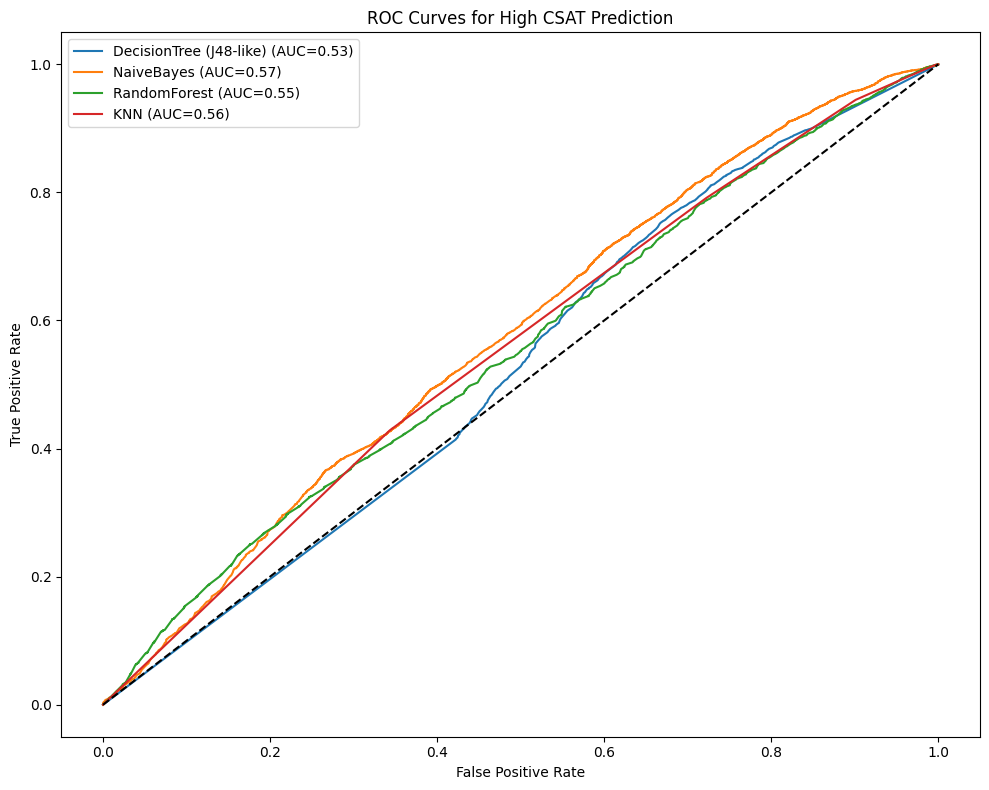

In [ ]:
# --------------------------------------------------
# 7. TRAIN-TEST SPLIT
# --------------------------------------------------

X = dfClean.drop(columns=["high_csat"])
y = dfClean["high_csat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --------------------------------------------------
# 8. TRAIN MODELS
# --------------------------------------------------

models = {
    "DecisionTree (J48-like)": DecisionTreeClassifier(random_state=42),
    "NaiveBayes": GaussianNB(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probability for ROC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({"model": name, "accuracy": acc, "roc_auc": roc_auc})

    # Plot ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ROC plot
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for High CSAT Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

##4. Accuracy Comparison


Model Comparison:
                     model  accuracy   roc_auc
0  DecisionTree (J48-like)  0.764599  0.527447
1               NaiveBayes  0.807357  0.574471
2             RandomForest  0.743375  0.553741
3                      KNN  0.796221  0.556080


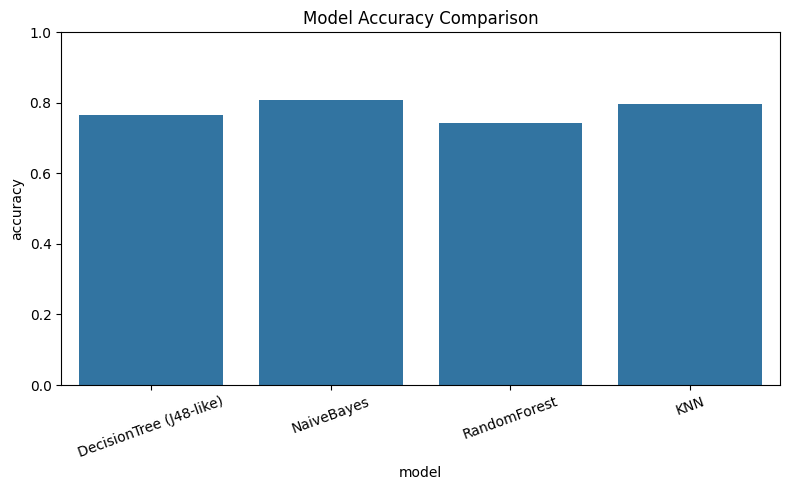


Best Model: NaiveBayes
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            471           4050
True_HighCSAT           915          20337


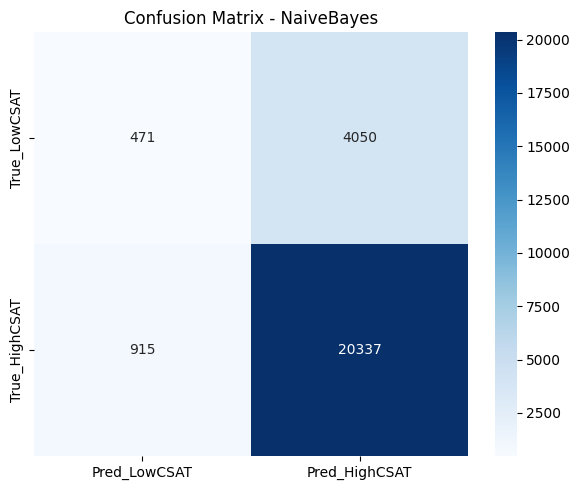

In [ ]:
# --------------------------------------------------
# 9. ACCURACY COMPARISON
# --------------------------------------------------

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="model", y="accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

# --------------------------------------------------
# 10. CONFUSION MATRIX FOR BEST MODEL
# --------------------------------------------------

best_model_name = results_df.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

print(f"\nBest Model: {best_model_name}")
print("Confusion Matrix:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Assuming y_test and y_pred_best are available from the previous step
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Low CSAT', 'High CSAT']))


Classification Report for NaiveBayes:
              precision    recall  f1-score   support

    Low CSAT       0.34      0.10      0.16      4521
   High CSAT       0.83      0.96      0.89     21252

    accuracy                           0.81     25773
   macro avg       0.59      0.53      0.53     25773
weighted avg       0.75      0.81      0.76     25773



### Addressing Class Imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original class distribution: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled class distribution: {Counter(y_train_res)}")

Original class distribution: Counter({1: 49584, 0: 10550})
Resampled class distribution: Counter({1: 49584, 0: 49584})


Now that the training data is balanced, let's retrain the models and evaluate their performance again.

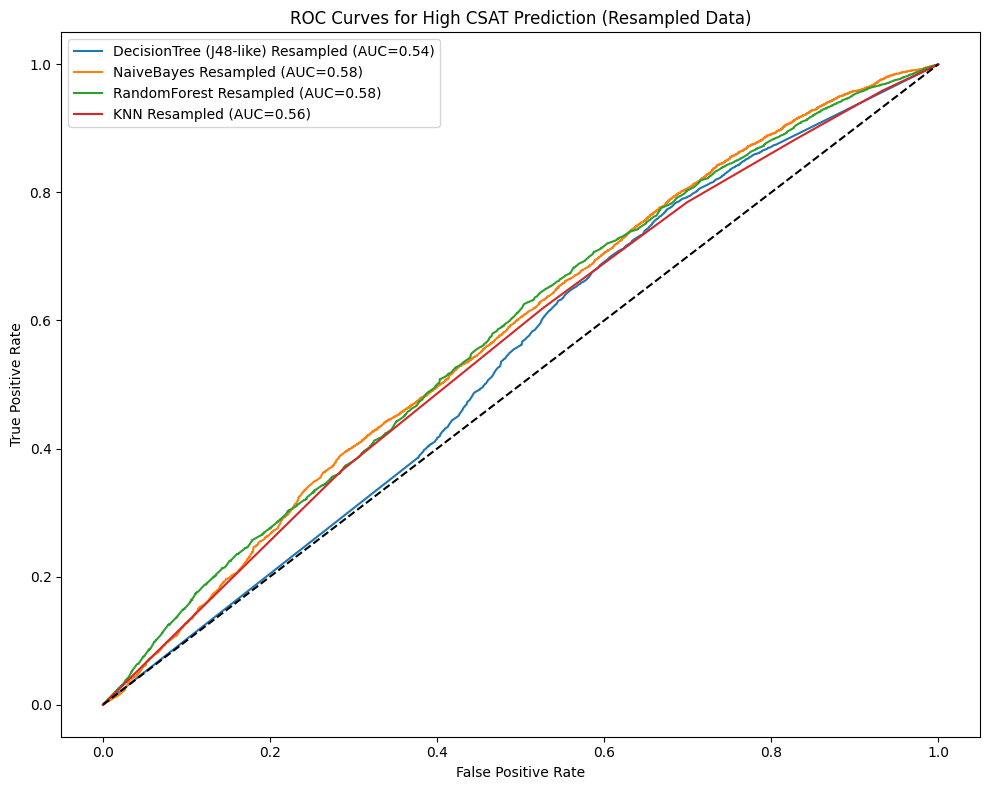


Model Comparison (Resampled Data):
                               model  accuracy   roc_auc
0  DecisionTree (J48-like) Resampled  0.661894  0.538967
1               NaiveBayes Resampled  0.803942  0.577067
2             RandomForest Resampled  0.685912  0.578549
3                      KNN Resampled  0.699686  0.561601


/tmp/ipykernel_3486/2980267007.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined_results_df, x="model", y="accuracy", palette="viridis")


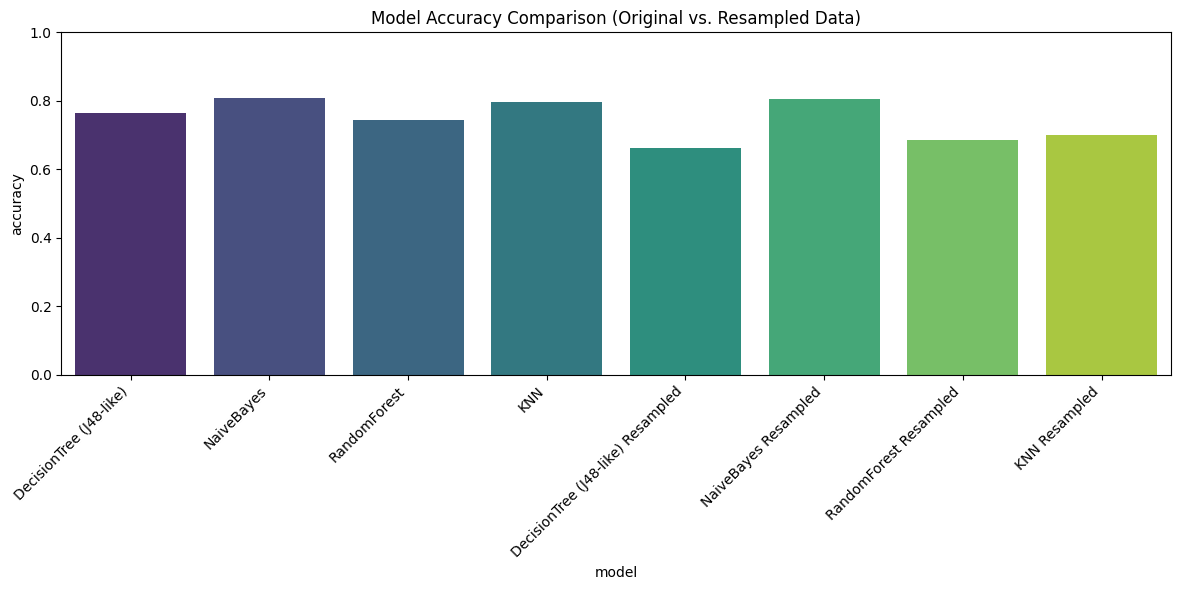


Best Model (Resampled Data): NaiveBayes Resampled
Confusion Matrix (Resampled Data):
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            537           3984
True_HighCSAT          1069          20183


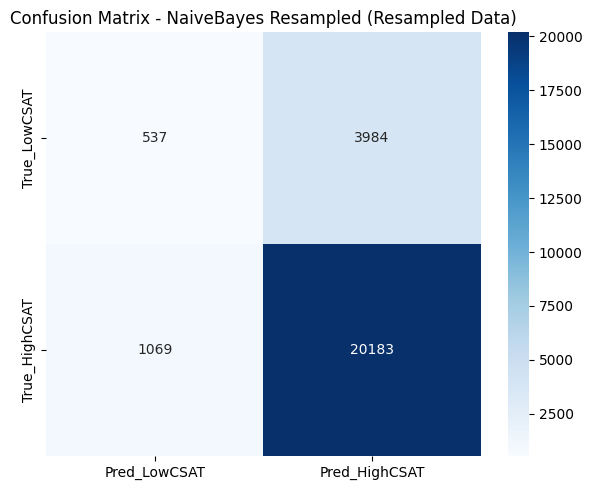


Classification Report for NaiveBayes Resampled (Resampled Data):
              precision    recall  f1-score   support

    Low CSAT       0.33      0.12      0.18      4521
   High CSAT       0.84      0.95      0.89     21252

    accuracy                           0.80     25773
   macro avg       0.58      0.53      0.53     25773
weighted avg       0.75      0.80      0.76     25773



In [ ]:
models_resampled = {
    "DecisionTree (J48-like) Resampled": DecisionTreeClassifier(random_state=42),
    "NaiveBayes Resampled": GaussianNB(),
    "RandomForest Resampled": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN Resampled": KNeighborsClassifier(n_neighbors=5)
}

results_resampled = []

plt.figure(figsize=(10, 8))

for name, model in models_resampled.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results_resampled.append({"model": name, "accuracy": acc, "roc_auc": roc_auc})

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for High CSAT Prediction (Resampled Data)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves_resampled.png", dpi=150)
plt.show()

results_df_resampled = pd.DataFrame(results_resampled)
print("\nModel Comparison (Resampled Data):")
print(results_df_resampled)

# Combine original and resampled results for a comprehensive comparison
combined_results_df = pd.concat([results_df, results_df_resampled])

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_results_df, x="model", y="accuracy", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison (Original vs. Resampled Data)")
plt.tight_layout()
plt.savefig("accuracy_comparison_combined.png", dpi=150)
plt.show()

best_model_name_resampled = results_df_resampled.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
best_model_resampled = models_resampled[best_model_name_resampled]

y_pred_best_resampled = best_model_resampled.predict(X_test)
cm_resampled = confusion_matrix(y_test, y_pred_best_resampled)

cm_df_resampled = pd.DataFrame(
    cm_resampled,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

print(f"\nBest Model (Resampled Data): {best_model_name_resampled}")
print("Confusion Matrix (Resampled Data):")
print(cm_df_resampled)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df_resampled, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name_resampled} (Resampled Data)")
plt.tight_layout()
plt.savefig("confusion_matrix_resampled.png", dpi=150)
plt.show()

print(f"\nClassification Report for {best_model_name_resampled} (Resampled Data):")
print(classification_report(y_test, y_pred_best_resampled, target_names=['Low CSAT', 'High CSAT']))

In [ ]:
from sklearn.metrics import classification_report

print(f"\nClassification Report for {best_model_name_resampled} (Resampled Data):")
print(classification_report(y_test, y_pred_best_resampled, target_names=['Low CSAT', 'High CSAT']))